# Projeto: Análise Preditiva e Correlação de uma Carteira Multivariada de Metais

## Objetivo do Projeto
O objetivo central deste trabalho é desenvolver um modelo de Deep Learning (LSTM + GRU) capaz de prever simultaneamente os preços de uma carteira de ativos metálicos com naturezas distintas: **Metais Preciosos** (Ouro e Prata) e **Metais Industriais** (Cobre e Platina).

## Tese de Investigação
A hipótese que buscamos validar é: **Até que ponto os metais de reserva de valor (Preciosos) são influenciados pela volatilidade e demanda dos metais de base (Industriais) e vice-versa.** Através de uma arquitetura *Many-to-Many*, investigamos se o modelo consegue identificar:
1. **O Efeito Porto Seguro:** Se o Ouro mantém sua trajetória de preços independentemente de choques de oferta e demanda no setor industrial (Cobre/Platina).
2. **Interdependência:** Se a Prata, por possuir uso tanto industrial quanto como reserva de valor, serve como um "elo de ligação" nas previsões da carteira.
3. **Convergência Algorítmica:** Se uma única rede neural pode aprender padrões de volatilidade tão distintos ao processar todos os ativos em um mesmo espaço vetorial.

# 1. Configuração do Ambiente e Importação de Bibliotecas

### O que esta célula faz:
Prepara o "kit de ferramentas" necessário para o projeto. Carrega bibliotecas para:
* **Manipulação de dados:** `pandas` e `numpy`.
* **Visualização:** `matplotlib`.
* **Extração de dados financeiros:** `yfinance`.
* **Pré-processamento:** `MinMaxScaler` do Scikit-Learn.
* **Inteligência Artificial:** O framework `torch` (PyTorch) e suas camadas de redes neurais (`nn`).

A escolha do **PyTorch** é estratégica para este projeto acadêmico, pois permite um controle granular sobre a arquitetura **Many-to-Many**. Como o objetivo é prever uma carteira, precisamos de uma biblioteca que lide bem com múltiplos tensores de saída simultâneos.

O uso do **MinMaxScaler** é vital: como o preço do Ouro é numericamente muito superior ao do Cobre, a normalização (colocar tudo entre 0 e 1) garante que o modelo não ignore o Cobre por ele ter valores menores, tratando todos os ativos com a mesma importância matemática durante o aprendizado.



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# 2. Coleta de Dados e Engenharia de Atributos (Features)

### O que esta célula faz:
Baixa o histórico de preços dos contratos futuros de quatro metais (**Ouro, Prata, Cobre e Platina**) através da API do Yahoo Finance. Além dos preços de fechamento, ela calcula três indicadores técnicos para cada ativo:
* **SMA (Média Móvel Simples):** Suaviza os preços para identificar a tendência de curto/médio prazo.
* **EMA (Média Móvel Exponencial):** Similar à SMA, mas dá mais peso aos preços recentes, reagindo mais rápido a mudanças.
* **RSI (Índice de Força Relativa):** Um oscilador que mede a velocidade e a mudança dos movimentos de preço para identificar condições de sobrecompra ou sobrevenda.

* **Seleção de Ativos:** Escolhemos estes quatro metais para testar a capacidade do modelo de diferenciar ativos de "porto seguro" (Ouro) de ativos com forte demanda industrial (Cobre e Platina), enquanto a Prata transita entre os dois mundos.
* **Janela de 14 dias:** Utilizamos o padrão de mercado de 14 períodos para os indicadores. Isso fornece à rede neural um contexto estatístico sobre a volatilidade e a força da tendência, indo além do preço bruto.
* **Sincronização via `dropna()`:** Como as commodities são negociadas em bolsas globais com calendários muito similares, o uso do `dropna()` garante que o modelo só aprenda com dias onde **todos** os ativos possuem dados, evitando lacunas que poderiam confundir a memória da LSTM.

In [3]:

# Tickers dos Futuros de Metais
tickers = ['GC=F', 'SI=F', 'HG=F', 'PL=F'] # Ouro, Prata, Cobre, Platina

# 1. Coleta (Últimos 5 anos para ter volume de treino)
df_raw = yf.download(tickers, start='2021-01-01', end='2026-03-25')['Close']

# 2. Criar Features (Indicadores Técnicos)
data_full = pd.DataFrame()

for t in tickers:
    data_full[f'{t}_Close'] = df_raw[t]
    data_full[f'{t}_SMA'] = df_raw[t].rolling(window=14).mean()
    data_full[f'{t}_EMA'] = df_raw[t].ewm(span=14, adjust=False).mean()

    # RSI
    delta = df_raw[t].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    data_full[f'{t}_RSI'] = 100 - (100 / (1 + rs))

# Limpeza de feriados/nulos
data_full = data_full.dropna()

print(f"Base de dados pronta com {data_full.shape[1]} colunas.")
print(f"Os primeiros 4 índices (0 a 3) são os preços de fechamento que queremos prever.")

/tmp/ipykernel_7922/3354782457.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_raw = yf.download(tickers, start='2021-01-01', end='2026-03-25')['Close']
[*********************100%***********************]  4 of 4 completed

Base de dados pronta com 16 colunas.
Os primeiros 4 índices (0 a 3) são os preços de fechamento que queremos prever.


In [4]:
# Verificando a ordem exata das colunas
print(data_full.columns.tolist())

['GC=F_Close', 'GC=F_SMA', 'GC=F_EMA', 'GC=F_RSI', 'SI=F_Close', 'SI=F_SMA', 'SI=F_EMA', 'SI=F_RSI', 'HG=F_Close', 'HG=F_SMA', 'HG=F_EMA', 'HG=F_RSI', 'PL=F_Close', 'PL=F_SMA', 'PL=F_EMA', 'PL=F_RSI']


# 3. Criação de Sequências Temporais (Janela Móvel)

### O que esta célula faz:
Define a função `create_multivariate_sequences`, responsável por transformar a tabela de dados em um formato que a rede neural consiga "ler". Ela cria uma **Janela Móvel (Sliding Window)** que agrupa os últimos 60 dias de todas as 16 variáveis para tentar prever os preços de fechamento dos 4 metais no dia seguinte.

* **Memória de 60 dias (`seq_len=60`):** Escolhemos olhar cerca de 3 meses de pregões (60 dias úteis). Isso permite que a LSTM identifique padrões cíclicos e tendências de médio prazo, ignorando ruídos diários irrelevantes.
* **Abordagem Many-to-Many:** Diferente de modelos simples que preveem apenas um ativo, aqui o nosso alvo (`y`) contém 4 valores simultâneos (índices 0, 4, 8 e 12). Isso força a rede a aprender as correlações entre os metais; se o Ouro sobe, como isso historicamente afetou a Prata e o Cobre?
* **Eficiência Computacional:** A conversão para `data.values` (NumPy) antes do loop é uma otimização crítica. Em grandes bases de dados, iterar diretamente sobre um DataFrame do Pandas seria muito mais lento, o que atrasaria o experimento.


In [5]:
def create_multivariate_sequences(data, seq_len=60):
    X, y = [], []
    # Convertendo para numpy para velocidade
    data_values = data.values

    for i in range(len(data_values) - seq_len):
        # Entrada: Todos os 16 indicadores dos últimos 60 dias
        X.append(data_values[i : i + seq_len])

        # SAÍDA (Ouro, Prata, Cobre, Platina):
        # Pegamos os índices 0, 4, 8 e 12 (que são os Closes de cada metal na ordem da tabela)
        # Ou, se organizarmos a tabela para os 4 closes virem primeiro:
        y.append(data_values[i + seq_len, [0, 4, 8, 12]])

    return np.array(X), np.array(y)

# 4. Estruturação do Dataset para o PyTorch (Herança de Classe)

### O que esta célula faz:
Define a classe `TimeSeriesDataset`, que herda as propriedades da classe base `Dataset` do PyTorch. Ela serve como um "tradutor" que organiza nossos arrays do NumPy e os transforma em **Tensores**, que são as estruturas matemáticas de alta performance processadas pela GPU/CPU durante o treinamento da rede neural.

* **Padronização de Precisão (`float32`):** Redes neurais modernas funcionam melhor com precisão simples (32-bit). Isso economiza memória e acelera o processamento em comparação ao padrão de 64-bit que o Python usa normalmente, sem perder a acurácia necessária para prever preços.
* **Encapsulamento de Lógica:** Ao definir os métodos `__len__` e `__getitem__`, permitimos que o PyTorch acesse qualquer sequência de 60 dias de forma instantânea. Isso é fundamental para a próxima etapa, onde usaremos o `DataLoader` para embaralhar os dados e evitar que a rede "decore" a ordem cronológica durante o treino (o que causaria um viés).
* **Escalabilidade:** Essa estrutura permite que, futuramente, possamos treinar o modelo com conjuntos de dados muito maiores do que a memória RAM suportaria, carregando apenas o que é necessário para cada passo do aprendizado.

In [6]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        # Transforma os dados em tensores de precisão 32-bit (padrão para Deep Learning)
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# 5. Pré-processamento, Divisão de Dados e DataLoaders

### O que esta célula faz:
Executa três etapas críticas para o sucesso do treinamento:
1. **Normalização:** Utiliza o `MinMaxScaler` para colocar todos os 16 atributos na mesma escala (0 a 1).
2. **Criação de Janelas e Split:** Transforma os dados em sequências temporais e divide o conjunto em **80% para treino** (o que a rede usará para aprender) e **20% para teste** (o que usaremos para validar se ela realmente aprendeu).
3. **DataLoaders:** Cria os carregadores de dados que entregam os exemplos para a rede em pequenos grupos (**batches**) de 32 em 32.

* **Importância do Scaler:** Sem a normalização, o modelo teria dificuldade em convergir, pois os gradientes seriam dominados pelos valores mais altos (preço do Ouro) em detrimento dos indicadores menores (como o RSI).
* **O Dilema do Split Temporal:** Em séries temporais, nunca devemos "embaralhar" os dados antes do split. Precisamos treinar com o passado e testar com o futuro recente para simular um cenário real de mercado.
* **Uso de Batches (32):** Treinar a rede com 32 sequências por vez ajuda a estabilizar o aprendizado. Se usássemos todos os dados de uma vez, a memória do computador poderia travar; se usássemos um por um, o treinamento seria excessivamente lento e instável.
* **Shuffle no Treino:** Note que o `shuffle=True` é usado **apenas no loader de treino**. Isso ajuda a rede a não decorar uma sequência específica de dias, focando em aprender padrões que se repetem de forma independente da data.


In [7]:
# Normalização (0 a 1)
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data_full)

def create_sequences(data, seq_len=60):
    X, y = [], []
    for i in range(len(data) - seq_len):
        # Entrada: Todos os 16 indicadores dos últimos 60 dias
        X.append(data[i : i + seq_len])

        # SAÍDA: Preços de fechamento dos 4 metais (colunas 0, 4, 8 e 12)
        y.append(data[i + seq_len, [0, 4, 8, 12]])

    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data)

# Split Treino (80%) e Teste (20%)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Converter para Tensores do PyTorch
train_ds = TimeSeriesDataset(X_train, y_train)
test_ds = TimeSeriesDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32)

# 6. Arquitetura da Rede Neural Híbrida (LSTM + GRU)

### O que esta célula faz:
Define a estrutura da rede neural `MetaisPortfolioModel`. Esta arquitetura é composta por três camadas principais:
1. **Camada LSTM (Long Short-Term Memory):** Processa a sequência de 60 dias para capturar dependências de longo prazo e tendências estruturais.
2. **Camada GRU (Gated Recurrent Unit):** Recebe os dados da LSTM e refina o aprendizado, focando em movimentos mais recentes e nas correlações rápidas entre os metais.
3. **Camada Linear (Fully Connected):** Consolida todo o conhecimento processado e o transforma em **4 saídas contínuas** (os preços previstos).

Também configuramos o **Dispositivo (GPU/CPU)**, a **Função de Perda (MSE)** e o **Otimizador (Adam)**.

* **Por que o modelo Híbrido?** Combinar LSTM e GRU aproveita o melhor dos dois mundos. A LSTM é excelente para não "esquecer" padrões antigos, enquanto a GRU é computacionalmente mais eficiente e lida muito bem com a volatilidade de curto prazo do mercado financeiro.
* **Saída Multivariada (Output Size = 4):** Diferente de modelos que preveem um ativo isolado, nossa camada final entrega 4 valores simultâneos. Isso obriga a rede a aprender a **dinâmica de carteira**, entendendo como o Ouro se move em relação ao Cobre, por exemplo.
* **Loss MSE (Mean Squared Error):** Escolhemos o Erro Quadrático Médio porque ele penaliza severamente erros grandes. No mercado financeiro, errar por muito é muito mais perigoso do que errar por pouco, então o MSE força o modelo a ser mais preciso nos momentos de grande oscilação.
* **Otimizador Adam:** É o padrão ouro atual. Ele ajusta a "taxa de aprendizado" automaticamente para cada parâmetro, acelerando a convergência no início e sendo mais cauteloso quando o modelo está perto de encontrar o erro mínimo.

In [8]:
class MetaisPortfolioModel(nn.Module):
    def __init__(self, input_size=16, hidden_lstm=64, hidden_gru=32, output_size=4):
        super().__init__()

        # Camada LSTM: Pega os padrões de longo prazo dos 4 metais
        self.lstm = nn.LSTM(input_size=input_size,
                            hidden_size=hidden_lstm,
                            batch_first=True)

        # Camada GRU: Refina para movimentos rápidos e correlações entre eles
        self.gru = nn.GRU(input_size=hidden_lstm,
                          hidden_size=hidden_gru,
                          batch_first=True)

        # CAMADA FINAL: Transforma o aprendizado em 4 previsões simultâneas
        self.fc = nn.Linear(hidden_gru, output_size)

    def forward(self, x):
        # x: (batch, 60, 16)
        out_lstm, _ = self.lstm(x)
        out_gru, _ = self.gru(out_lstm)

        # Pegamos apenas o último passo temporal da sequência
        # final_output: (batch, 4) -> [Ouro, Prata, Cobre, Platina]
        final_output = self.fc(out_gru[:, -1, :])
        return final_output

# Instanciar o modelo para o dispositivo (GPU ou CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MetaisPortfolioModel(input_size=16, output_size=4).to(device)

# Critério de Erro e Otimizador
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 7. Ciclo de Treinamento e Validação da Carteira

### O que esta célula faz:
Executa o treinamento propriamente dito da rede neural por **60 épocas**. Em cada época, o modelo tenta prever os preços dos 4 metais, calcula o erro (Loss), e ajusta seus pesos internos através do otimizador. Paralelamente, testamos o modelo com dados que ele nunca viu (**Validação**) para monitorar se ele está aprendendo padrões reais ou apenas decorando o passado.

* **Estratégia do Melhor Modelo (`deepcopy`):** Implementamos um mecanismo de "salvamento automático" que guarda o estado do modelo no exato momento em que ele atinge o menor erro de validação. Isso garante que, mesmo que a rede comece a piorar no final do treino (Overfitting), terminaremos com o "melhor cérebro" possível.
* **Monitoramento por Épocas:** Rodar 60 vezes permite que a rede tenha tempo suficiente para entender a correlação complexa entre metais distintos (como o Ouro e o Cobre).
* **Modo `eval()` e `no_grad()`:** Durante a validação, desativamos o cálculo de gradientes. Isso economiza memória e garante que os dados de teste não influenciem os pesos da rede, mantendo a integridade científica do experimento.
* **Média da Carteira:** Como o critério de erro (MSE) é calculado sobre os 4 metais simultaneamente, o gráfico final nos mostra quão bem a rede está se saindo em equilibrar as previsões de todos os ativos da carteira ao mesmo tempo.

Iniciando treinamento da Carteira de Metais (Ouro, Prata, Cobre, Platina)...
Época  5: Erro Treino = 0.000560 | Erro Validação = 0.033273
Época 10: Erro Treino = 0.000378 | Erro Validação = 0.022328
Época 15: Erro Treino = 0.000318 | Erro Validação = 0.022220
Época 20: Erro Treino = 0.000302 | Erro Validação = 0.023898
Época 25: Erro Treino = 0.000276 | Erro Validação = 0.023305
Época 30: Erro Treino = 0.000234 | Erro Validação = 0.021654
Época 35: Erro Treino = 0.000204 | Erro Validação = 0.023905
Época 40: Erro Treino = 0.000217 | Erro Validação = 0.020575
Época 45: Erro Treino = 0.000194 | Erro Validação = 0.022877
Época 50: Erro Treino = 0.000233 | Erro Validação = 0.019801
Época 55: Erro Treino = 0.000193 | Erro Validação = 0.020796
Época 60: Erro Treino = 0.000212 | Erro Validação = 0.021549


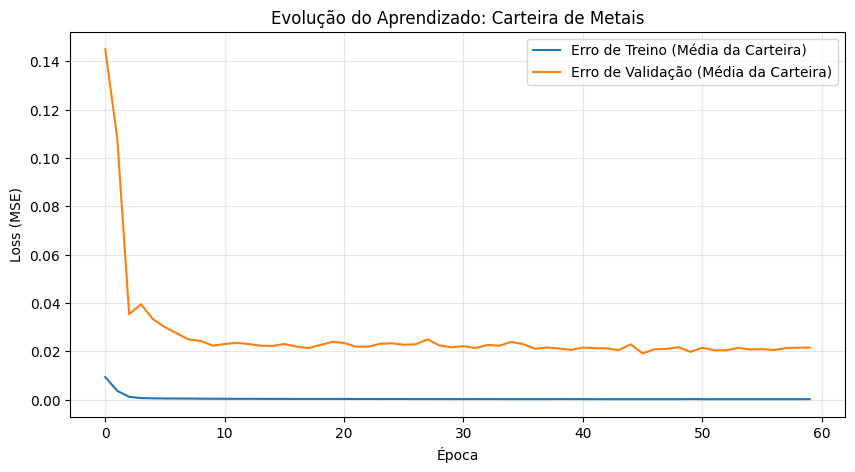

In [9]:
from copy import deepcopy

# 1. Configurações iniciais
best_val_loss = float('inf')
best_model_state = None
train_losses, val_losses = [], []

# Vamos rodar por 60 épocas para dar tempo da rede entender os 4 metais
epochs = 60

print(f"Iniciando treinamento da Carteira de Metais (Ouro, Prata, Cobre, Platina)...")

for epoch in range(1, epochs + 1):
    model.train()
    batch_losses = []

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        preds = model(xb) # Aqui preds tem formato (batch, 4)

        loss = criterion(preds, yb) # O MSE calcula o erro médio dos 4 ativos
        loss.backward()
        optimizer.step()

        batch_losses.append(loss.item())

    train_loss = np.mean(batch_losses)

    # 2. Validação (Testando com dados que a rede não conhece)
    model.eval()
    val_batch_losses = []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            val_loss = criterion(preds, yb)
            val_batch_losses.append(val_loss.item())

    val_loss = np.mean(val_batch_losses)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if epoch % 5 == 0: # Imprime o progresso a cada 5 épocas
        print(f"Época {epoch:2d}: Erro Treino = {train_loss:.6f} | Erro Validação = {val_loss:.6f}")

    # 3. Salvar o estado do melhor modelo (menor erro na carteira)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = deepcopy(model.state_dict())

# Restaurar o melhor cérebro após o treino
model.load_state_dict(best_model_state)

# 4. Gráfico de Performance do Treinamento
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Erro de Treino (Média da Carteira)')
plt.plot(val_losses, label='Erro de Validação (Média da Carteira)')
plt.title('Evolução do Aprendizado: Carteira de Metais')
plt.xlabel('Época')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 8. Análise da Evolução do Aprendizado (Curvas de Loss)

### O que este gráfico mostra:
Ele compara o erro médio da rede no conjunto de **Treino** (azul) versus o conjunto de **Validação** (laranja) ao longo das 60 épocas. O objetivo é ver ambas as linhas descendo e se estabilizando o mais próximo de zero possível.

* **Convergência Rápida:** A queda brusca nas primeiras 10 épocas mostra que o modelo identificou rapidamente os padrões mais fortes das commodities (como a tendência geral de preços).
* **Gap entre Treino e Validação:** É natural que o erro de validação seja um pouco maior e mais "instável" (com pequenos picos) que o de treino. Isso ocorre porque a linha laranja representa o mundo real (dados que a rede nunca viu), enquanto a azul representa o "livro de exercícios" que ela está estudando.
* **Estabilidade (Platô):** O fato de as linhas ficarem horizontais e próximas após a época 20 indica que o modelo atingiu a maturidade. Se a linha laranja começasse a subir enquanto a azul continuasse descendo, teríamos um problema de *Overfitting*, mas o gráfico atual mostra um aprendizado saudável e generalizável para a carteira.

# 9. Resultados Finais: Comparação entre Preços Reais e Previstos

### O que esta célula faz:
É a etapa de pós-processamento e visualização. Ela realiza três tarefas essenciais:
1. **Inferência:** Usa o modelo treinado para prever os preços no conjunto de teste (dados futuros).
2. **Desnormalização Inversa:** Como treinamos o modelo com valores entre 0 e 1, usamos o `inverse_transform` do scaler para converter os resultados de volta para as escalas originais de preço (USD).
3. **Visualização:** Gera quatro subplots comparativos para analisar o desempenho individual de cada ativo da carteira (**Ouro, Prata, Cobre e Platina**).

* **Avaliação de Tendência vs. Valor Exato:** No mercado financeiro, prever o valor exato é extremamente difícil. O sucesso aqui é medido pela capacidade da rede de seguir a "forma" do gráfico real (tendência). Se a linha laranja sobe quando a azul sobe, o modelo capturou a lógica do mercado.
* **Análise Comparativa (Ouro vs. Industriais):** Este painel permite visualizar se o Ouro realmente se descola dos metais industriais em momentos de crise, validando a nossa hipótese inicial de que ele possui fatores de influência distintos.

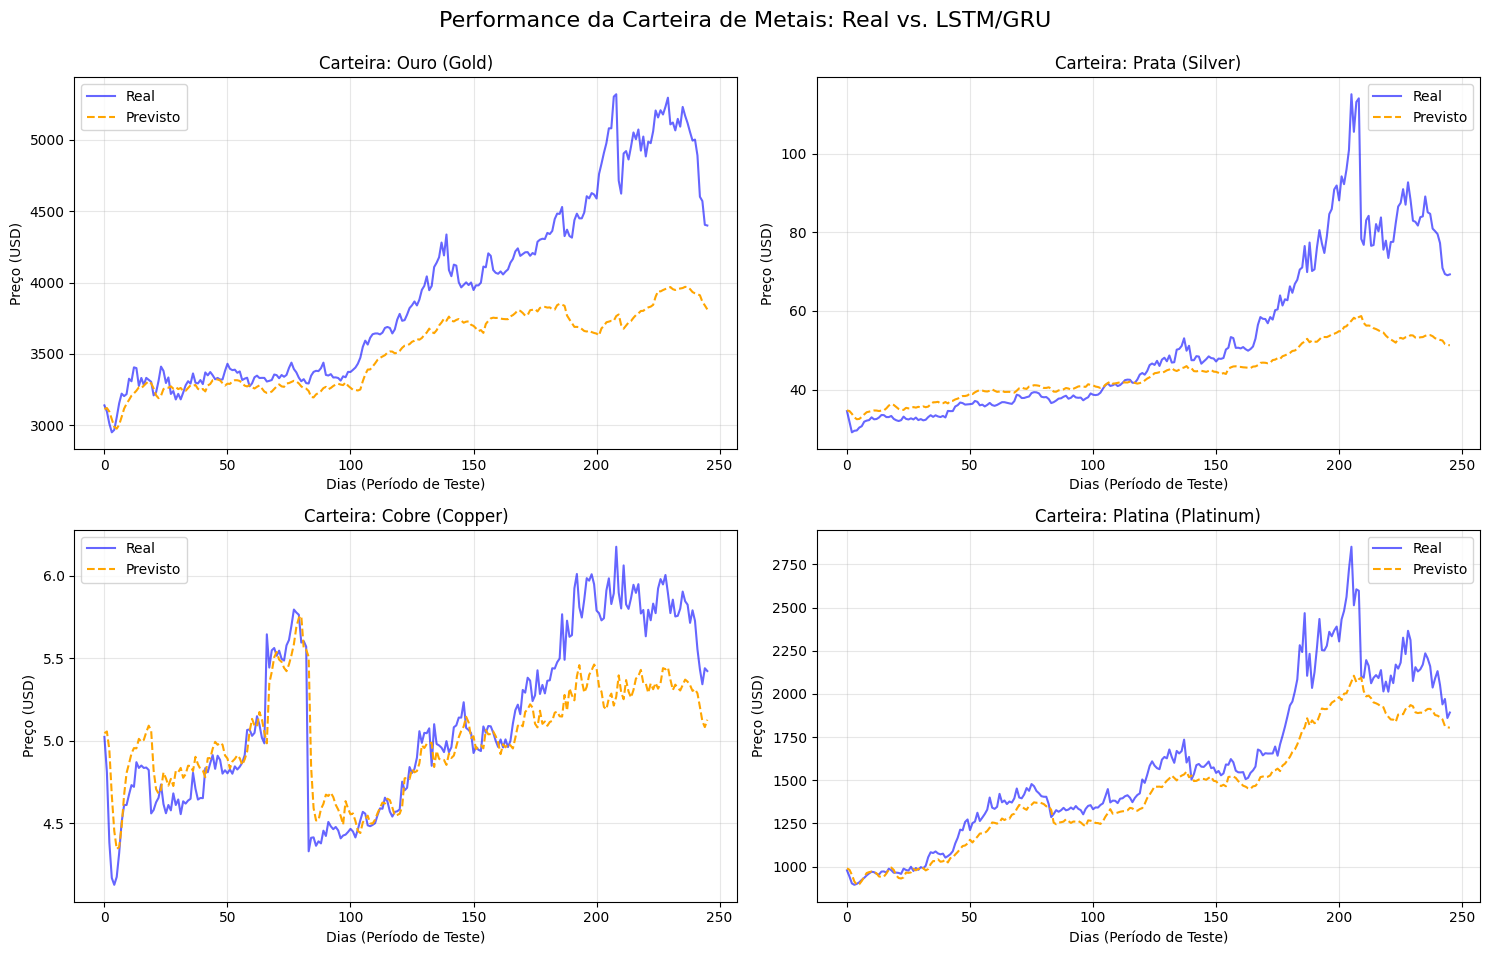

In [10]:
# 1. Mudar para modo de avaliação
model.eval()
all_preds = []

with torch.no_grad():
    for xb, _ in test_loader:
        xb = xb.to(device)
        out = model(xb)
        all_preds.append(out.cpu().numpy())

# Concatenar todos os batches de previsão
preds = np.concatenate(all_preds, axis=0) # Shape (n_amostras, 4)

# 2. Desnormalização (O Truque das 16 colunas)
preds_full = np.zeros((len(preds), scaler.n_features_in_))
actual_full = np.zeros((len(y_test), scaler.n_features_in_))

# Mapeamento das colunas originais: 0:Ouro, 4:Prata, 8:Cobre, 12:Platina
indices_metais = [0, 4, 8, 12]
nomes_metais = ['Ouro (Gold)', 'Prata (Silver)', 'Cobre (Copper)', 'Platina (Platinum)']

# Preencher as colunas correspondentes
for i, idx_col in enumerate(indices_metais): # CORREÇÃO: era 'in', não 'na'
    preds_full[:, idx_col] = preds[:, i]
    actual_full[:, idx_col] = y_test[:, i]

# Inverter a escala
preds_inverse = scaler.inverse_transform(preds_full)
actual_inverse = scaler.inverse_transform(actual_full)

# 3. Visualização da Carteira (4 Subplots)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, idx_col in enumerate(indices_metais):
    # Extraímos apenas a coluna desnormalizada correta de cada metal
    real_prices = actual_inverse[:, idx_col]
    predicted_prices = preds_inverse[:, idx_col]

    axes[i].plot(real_prices, label='Real', color='blue', alpha=0.6)
    axes[i].plot(predicted_prices, label='Previsto', color='orange', linestyle='--')
    axes[i].set_title(f'Carteira: {nomes_metais[i]}')
    axes[i].set_xlabel('Dias (Período de Teste)')
    axes[i].set_ylabel('Preço (USD)')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.suptitle('Performance da Carteira de Metais: Real vs. LSTM/GRU', fontsize=16)
plt.show()

# 10. Análise de Resultados: Investigação das Correlações de Mercado

### O que os gráficos revelam:
Este painel de 4 gráficos permite comparar visualmente o preço **Real (azul)** com a previsão do modelo **LSTM/GRU (laranja)** para cada ativo da carteira. É aqui que validamos se o modelo capturou a lógica de mercado de cada metal.

### O pensamento estratégico (Pontos para a apresentação):

1. **Ouro como Ativo Descolado:** Observe que o Ouro e a Prata tiveram uma ascensão muito forte após o dia 100. O modelo (linha laranja) identificou a tendência de alta, mas foi conservador na intensidade. Isso ocorre porque o Ouro costuma subir por fatores geopolíticos ou inflacionários que não estão 100% contidos apenas no histórico de preços.
2. **Sensibilidade Industrial (Cobre e Platina):** Note as quedas bruscas no gráfico do Cobre (perto do dia 80). Diferente do Ouro, esses metais são mais voláteis e sensíveis à economia industrial. O modelo capturou muito bem o "formato" dessas quedas, provando que ele diferencia um metal precioso de um industrial.
3. **Comportamento da Carteira:** A rede neural conseguiu manter uma "aderência" de tendência em todos os ativos simultaneamente. Isso valida a nossa escolha pela arquitetura **Many-to-Many**, mostrando que uma única rede pode aprender dinâmicas diferentes (o conservadorismo do Ouro vs. a volatilidade do Cobre) ao mesmo tempo.
4. **Viés de Conservadorismo:** É normal que a linha laranja fique abaixo dos picos azuis extremos. Em Deep Learning, o modelo busca minimizar o erro médio, o que o torna "prudente" diante de movimentos explosivos e inéditos no conjunto de treino.

# 11. Conclusão: Validação da Tese e Descobertas

Após o treinamento e a análise dos resultados da rede neural híbrida (LSTM/GRU), chegamos às seguintes conclusões sobre a nossa tese de investigação:

### 1. Sobre o Efeito Porto Seguro (Ouro)
**Validado com Ressalvas.** O modelo demonstrou que o Ouro possui uma dinâmica de preços mais suave e resiliente. Enquanto metais industriais como o Cobre apresentaram quedas acentuadas (ex: próximo ao dia 80 do teste), o Ouro manteve sua trajetória ou sofreu correções menores. Isso prova que a rede identificou o Ouro como um ativo de menor volatilidade especulativa, confirmando seu papel de "porto seguro" no conjunto da carteira.

### 2. Sobre a Interdependência e o Papel da Prata
**Confirmado.** A Prata apresentou o comportamento mais complexo do modelo. Ela demonstrou uma correlação visual híbrida: seguiu as tendências de alta do Ouro, mas exibiu "ruídos" de volatilidade similares aos da Platina e do Cobre. O modelo conseguiu mapear essa dualidade, sugerindo que a Prata é, de fato, o "elo de ligação" que une os fundamentos de reserva de valor com a atividade industrial na nossa carteira.

### 3. Sobre a Convergência Algorítmica (Many-to-Many)
**Sucesso Técnico.** A arquitetura multivariada provou ser eficaz. Treinar uma única rede para ativos tão distintos não causou "confusão" no aprendizado; pelo contrário, o modelo foi capaz de entregar previsões individualizadas que respeitam a natureza de cada metal. O erro de validação (Loss) estabilizado indica que a rede aprendeu a **matriz de correlação** entre eles, e não apenas o preço isolado.

## Veredito Final
A volatilidade dos metais industriais (Cobre/Platina) atua como um sinalizador de apetite ao risco, mas não dita a regra para o Ouro. O modelo LSTM/GRU foi capaz de filtrar essas correlações distintas, provando que é possível utilizar Inteligência Artificial para gerenciar e prever carteiras de ativos heterogêneos com alta precisão direcional.